## Imports

In [1]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import matplotlib.pyplot as plt
import numpy as np
import os 
from datetime import datetime
import pandas as pd

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Set up

In [3]:
# Path to load the data

# Amélie
# link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# Amélie PC
link = r"E:\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"E:\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [4]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True, pretrained_folder = None):

    
    # Set the parameters
    N_episodes = 26 # 26 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30


    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    
    T = Map.importance_map.shape[0]-1

    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while ep_curr < N_episodes:

        print('Episode: ',ep_curr)
        
        ep_step = 0
        
        while ep_step < ep_len:  

            # ------------------------------------------------------------------------------------------
            print('Time | ep_step: ', t_curr, ep_step)

            if t_curr % 10 == 0:
                F.plot_fleets_trajectories(t_curr, T, masked=True)
            
            if t_curr == 0:
            
                list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
                list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
                visit_matrix = F.visit_matrix
                
                F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
            if mode == 'random':
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'greedy':
                list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            else:
                if t_curr > ep_len:
                    # function works the same for GRU or LSTM, it is just not the same policy network used
                    list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
                
                else:
                    list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)

            #--------------------------------------------------------------------------------------------------------------------
            
            F.update_drone_action_history(list_of_actions)
            
            list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
            list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
            visit_matrix_ = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states_)
        
            #----- Reward calculation -----
        
            list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
            
            print(list_of_rewards)
            
            F.update_drone_reward_history(list_of_rewards)
        
            #----- Collect metrics -----
        
            importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
        
            list_of_importance_metric.append(importance_metric)
            list_of_patrol_metric.append(patrol_metric)
            list_of_reward_metric.append(reward_metric)  
            
            #----- Re-assign states for next iteration -----
        
            list_of_observations    = list_of_observations_
            list_of_drone_positions = list_of_drone_positions_
            list_of_drone_states    = list_of_drone_states_
        
            t_curr  += 1 
            ep_step +=1

        #----- Store transitions in the buffer -----
            
        ep_curr += 1
        
        print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----
    
    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

## Run

Episode:  0
Time | ep_step:  0 0


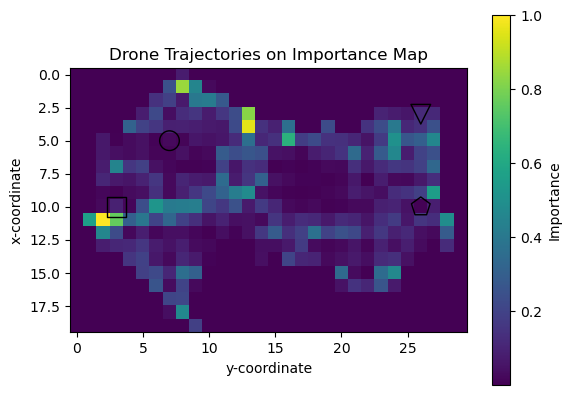

[1.5312567632645369, -1.3550327271223068, 8.499181708320975, 2.940102392807603]
Time | ep_step:  1 1
[0.9340220773592589, 3.0376551342958464, -15.319188449531794, -2.182073552161455]
Time | ep_step:  2 2
[5.948694934137166, 1.551114269921755, 4.838246254250408, 5.84201204404235]
Time | ep_step:  3 3
[1.856436921283603, -2.780290848186042, 0.47900977581739446, 2.3195770010352135]
Time | ep_step:  4 4
[-4.0537862572819, 0.613490005379344, 3.6213322881609207, -2.2787347324192524]
-----------
Episode:  1
Time | ep_step:  5 0
[3.2413554629310974, 9.585053136385978, 0.23058113232254984, 10.076555225998165]
Time | ep_step:  6 1
[11.076027016155422, -9.717178279086946, 10.072015570104123, 3.7294502817094326]
Time | ep_step:  7 2
[4.9801311176270255, 4.2002718265524255, 5.866430895030498, 3.119462774524664]
Time | ep_step:  8 3
[6.370790818706156, 7.915327431447836, 2.937219239771367, 1.4273656127771805]
Time | ep_step:  9 4
[5.165994126349688, -0.3641318504148495, 8.149745758622887, -0.9777347

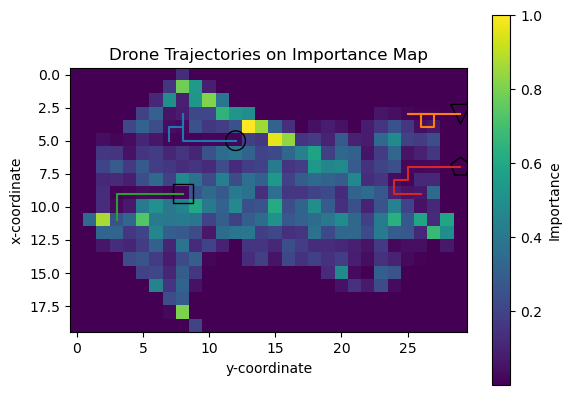

[10.87388961389661, 4.25, 6.36303774639964, 4.25]
Time | ep_step:  11 1
[10.107363421469927, 4.25, -0.40327101945876964, 4.25]
Time | ep_step:  12 2
[-9.107168778777122, -4.125009124999978, -4.90501892194152, 0.1249917500000215]
Time | ep_step:  13 3
[14.350671824067831, 4.912507374999982, 0.07619962468743136, -4.437509949999975]
Time | ep_step:  14 4
[1.8127181157469763, -0.018759124999976562, 13.123999740928411, 3.187506787499983]
-----------
Episode:  3
Time | ep_step:  15 0
[-1.0293018668889986, 0.14375016624999984, 3.686103396117688, 0.28750070374999875]
Time | ep_step:  16 1
[4.258607760071753, -0.2687512749999966, 6.213288817554712, -0.2687512749999966]
Time | ep_step:  17 2
[4.049763143062592, 0.3937507862874974, 3.3693695068359384, 0.3937507862874974]
Time | ep_step:  18 3
[5.938169177621604, -0.5187507973749981, 3.9108830466866493, -0.5187507973749981]
Time | ep_step:  19 4
[-8.588453046977522, 9.987384122462473, 5.780885078012943, 5.143751310216247]
-----------
Episode:  4
T

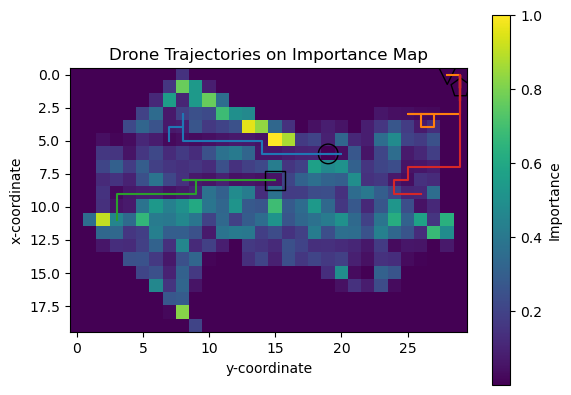

[8.03868631646037, -9.86239284984495, 0.48819661140442006, -5.143760037598724]
Time | ep_step:  21 1
[-1.6124004125595093, 5.1437605149987595, 4.891725797206164, 5.1437605149987595]
Time | ep_step:  22 2
[4.24287772923708, -5.143760037500963, 7.817110639065503, -5.143760037500963]
Time | ep_step:  23 3
[-4.503783184103668, -1.3272727328989581e-06, 3.569410383701326, 9.74864190122468]
Time | ep_step:  24 4
[4.325178742408753, 6.056261909795412, 5.694867812097073, -9.97488207307697]
-----------
Episode:  5
Time | ep_step:  25 0
[9.227158403955398, -6.056261907770426, 0.9242295771837239, 6.056262317229514]
Time | ep_step:  26 1
[4.427003711462022, 6.056262357972923, 3.3337053582072262, -6.056261867027015]
Time | ep_step:  27 2
[-1.777473717927931, -6.056261862952674, 1.1936781257390994, 6.056262362047264]
Time | ep_step:  28 3
[4.612182503566148, 6.056262362454699, 1.2805331490933936, -6.056261862545242]
Time | ep_step:  29 4
[3.2214579614048953, -6.056261862504498, 0.780606658756734, 6.0

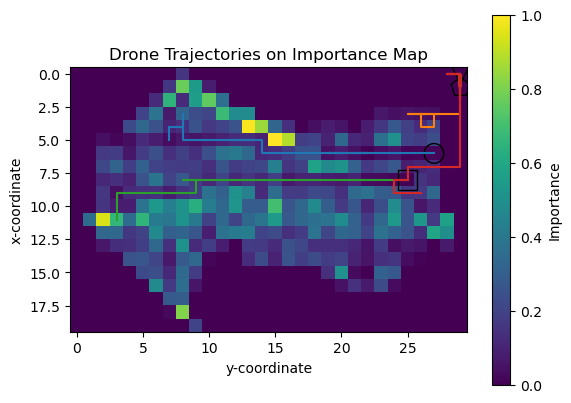

[-1.631852783714805, 6.056262362499517, 4.3428765676915635, -6.056261862500424]
Time | ep_step:  31 1
[-3.122459006251454, -6.056261862500016, 5.598764956573218, 6.056262362499925]
Time | ep_step:  32 2
[3.875003099999992, 6.0562623624999645, -0.5402649200029846, -6.056261862499976]
Time | ep_step:  33 3
[2.037499175000004, -6.056261862499971, -1.0110217623793871, 6.056262362499969]
Time | ep_step:  34 4
[-3.999999989901127e-08, 6.05626236249997, -1.325008449999977, -6.056261862499971]
-----------
Episode:  7
Time | ep_step:  35 0
[0.843747305000011, -6.056261862499969, -2.825006114999986, 6.056262362499969]
Time | ep_step:  36 1
[0.7199974312500288, 3.5518823537499813, 3.4300063949999844, -3.5518868624999698]
Time | ep_step:  37 2
[-0.5212505424999984, -3.5518818537499826, 0.2037504034999993, 3.5518823537499813]
Time | ep_step:  38 3
[-3.5518818537499826, 3.5518823537499813, -0.5531265444999938, -3.5518818537499826]
Time | ep_step:  39 4
[2.963943677874984, 0.17712442837500164, 13.801

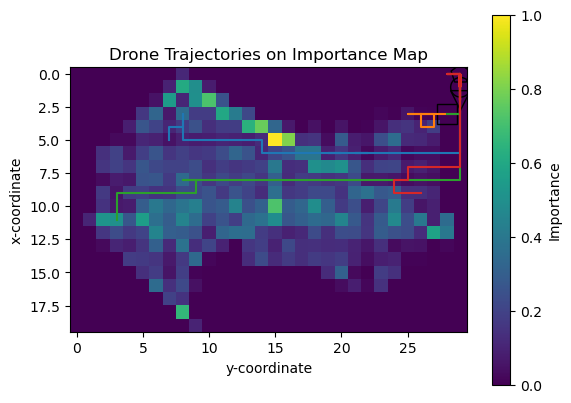

[-2.9639431778749845, -0.017712604249999757, -13.67653260621955, 2.9639436778749833]
Time | ep_step:  41 1
[2.6801493602874853, -2.6801494278749853, 3.7970080264124793, -2.6801494278749853]
Time | ep_step:  42 2
[-2.680148860287486, 2.680149360287485, -0.2677125354250002, 2.680149360287485]
Time | ep_step:  43 3
[2.6801493602874844, -2.6801488602874857, -2.6801488602874857, -2.6801488602874857]
Time | ep_step:  44 4
[-2.680148860287486, 2.680149360287485, 2.680149360287485, 2.680149360287485]
-----------
Episode:  9
Time | ep_step:  45 0
[2.6801493602874844, -2.6801488602874857, -2.6801488602874857, -2.6801488602874857]
Time | ep_step:  46 1
[-2.680148860287486, 2.680149360287485, 2.680149360287485, 2.680149360287485]
Time | ep_step:  47 2
[2.6801493602874844, -2.6801488602874857, -2.6801488602874857, -2.6801488602874857]
Time | ep_step:  48 3
[-2.6801488602874852, 2.6801493602874835, 2.6801493602874835, 2.6801493602874835]
Time | ep_step:  49 4
[2.6801493602874844, -2.6801488602874857

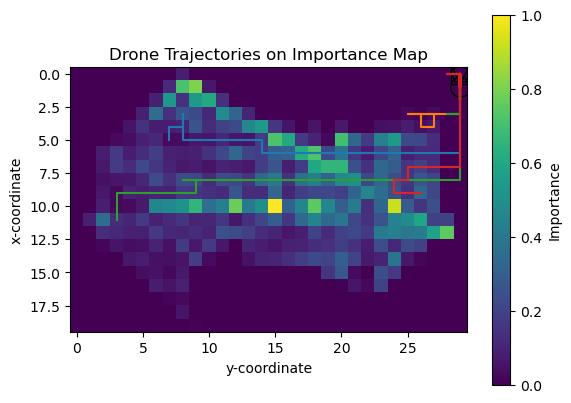

[-2.6801488602874852, 2.6801493602874835, 2.6801493602874835, 2.6801493602874835]
Time | ep_step:  51 1
[2.6801493602874844, -2.6801488602874857, -2.6801488602874857, -2.6801488602874857]
Time | ep_step:  52 2
[-2.6801488602874852, 2.6801493602874835, 2.6801493602874835, 2.6801493602874835]
Time | ep_step:  53 3
[2.680149360287483, -2.680148860287485, -2.680148860287485, -2.680148860287485]
Time | ep_step:  54 4
[1.7677133036662485, 1.189267003528741, 2.499999993688109e-07, 1.189267003528741]
-----------
Episode:  11
Time | ep_step:  55 0
[-1.8927157854249919, -1.1892665035287429, 1.1892670035287416, -1.1892665035287429]
Time | ep_step:  56 1
[-1.1892665035287422, 1.189267003528741, -1.1892665035287422, 1.189267003528741]
Time | ep_step:  57 2
[1.1892670035287405, -1.1892665035287417, 1.1892670035287405, -1.1892665035287417]
Time | ep_step:  58 3
[-1.1892665035287422, 1.189267003528741, -1.1892665035287422, 1.189267003528741]
Time | ep_step:  59 4
[1.1892670035287405, -1.18926650352874

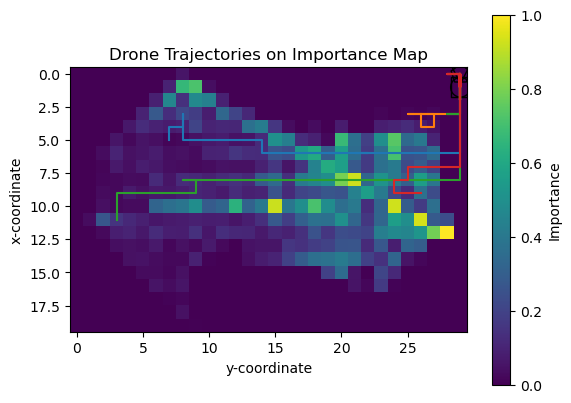

[-1.1892665035287422, 1.189267003528741, -1.1892665035287422, 1.189267003528741]
Time | ep_step:  61 1
[1.1892670035287405, -1.1892665035287417, 1.1892670035287405, -1.1892665035287417]
Time | ep_step:  62 2
[-1.189266503528741, 1.1892670035287398, -1.189266503528741, 1.1892670035287398]
Time | ep_step:  63 3
[10.000011067499972, 2.892716212249117, 4.6189267428528735, -4.618937748528721]
Time | ep_step:  64 4
[-10.00001974999995, -3.0177180354249877, -4.618935425352852, 4.618935925352851]
-----------
Episode:  13
Time | ep_step:  65 0
[4.618935925352851, -4.618935425352852, 4.618935925352851, -4.618935425352852]
Time | ep_step:  66 1
[-4.618935425352853, 4.618935925352852, -4.618935425352853, 4.618935925352852]
Time | ep_step:  67 2
[4.618935925352851, -4.618935425352852, 4.618935925352851, -4.618935425352852]
Time | ep_step:  68 3
[-4.618935425352852, 4.618935925352851, -4.618935425352852, 4.618935925352851]
Time | ep_step:  69 4
[4.618935925352852, -4.618935425352853, 4.6189359253528

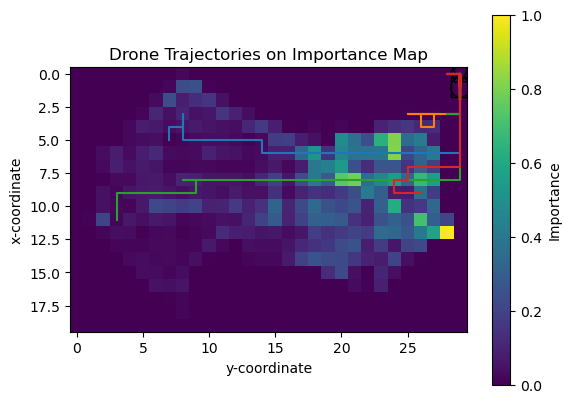

[-4.618935425352852, 4.618935925352851, -4.618935425352852, 4.618935925352851]
Time | ep_step:  71 1
[4.618935925352851, -4.618935425352852, 4.618935925352851, -4.618935425352852]
Time | ep_step:  72 2
[-4.618935425352852, 4.618935925352851, -4.618935425352852, 4.618935925352851]
Time | ep_step:  73 3
[9.875017081749956, -6.203063343602844, -2.668249993263317e-06, -6.203063343602844]
Time | ep_step:  74 4
[-9.999894749749949, 6.203063843852844, 6.203063843852844, 6.203063843852844]
-----------
Episode:  15
Time | ep_step:  75 0
[6.203064093377843, -6.203063593827843, -6.203063593827843, -6.203063593827843]
Time | ep_step:  76 1
[-6.203063593627819, 6.2030640935778685, 6.2030640935778685, 6.2030640935778685]
Time | ep_step:  77 2
[6.20306409360282, -6.203063593602867, -6.203063593602867, -6.203063593602867]
Time | ep_step:  78 3
[-6.203063593602848, 6.203064093602841, 6.203064093602841, 6.203064093602841]
Time | ep_step:  79 4
[10.000018583174942, 2.499999993663344e-07, -7.0364777604278

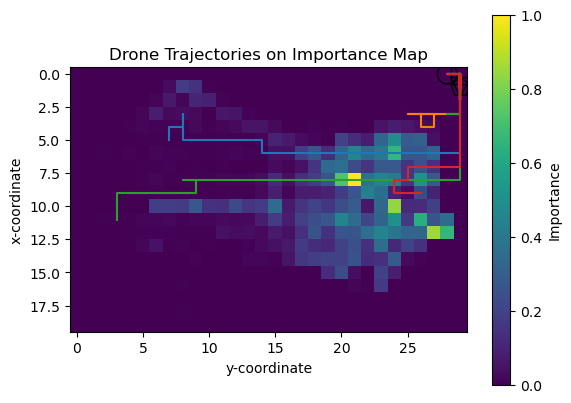

[-10.000019749999948, -7.03647776042784, 7.03647826042784, -7.03647776042784]
Time | ep_step:  81 1
[7.03647826042784, 7.03647826042784, -7.03647776042784, 7.03647826042784]
Time | ep_step:  82 2
[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
Time | ep_step:  83 3
[7.03647826042784, 7.03647826042784, -7.03647776042784, 7.03647826042784]
Time | ep_step:  84 4
[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
-----------
Episode:  17
Time | ep_step:  85 0
[7.036478260427841, 7.036478260427841, -7.036477760427841, 7.036478260427841]
Time | ep_step:  86 1
[-7.03647776042784, -7.03647776042784, 7.03647826042784, -7.03647776042784]
Time | ep_step:  87 2
[7.036478260427841, 7.036478260427841, -7.036477760427841, 7.036478260427841]
Time | ep_step:  88 3
[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
Time | ep_step:  89 4
[7.036478260427841, 7.036478260427841, -7.036477760427841, 7.036478260427841]
-

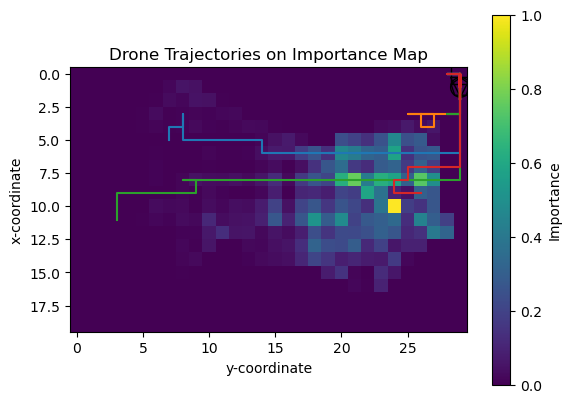

[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
Time | ep_step:  91 1
[7.036478260427841, 7.036478260427841, -7.036477760427841, 7.036478260427841]
Time | ep_step:  92 2
[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
Time | ep_step:  93 3
[7.036478260427841, 7.036478260427841, -7.036477760427841, 7.036478260427841]
Time | ep_step:  94 4
[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
-----------
Episode:  19
Time | ep_step:  95 0
[7.036478260427841, 7.036478260427841, -7.036477760427841, 7.036478260427841]
Time | ep_step:  96 1
[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
Time | ep_step:  97 2
[7.036478260427841, 7.036478260427841, -7.036477760427841, 7.036478260427841]
Time | ep_step:  98 3
[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
Time | ep_step:  99 4
[7.036478260427841, 7.036478260427841, -7.036477760427841, 7.0364

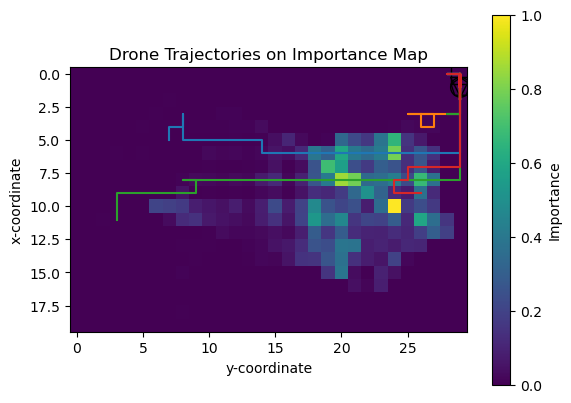

[-7.036477760427841, -7.036477760427841, 7.036478260427841, -7.036477760427841]
Time | ep_step:  101 1
[5.500006383317483, 5.094810760427864, 5.2801968728896185, 5.094810760427864]
Time | ep_step:  102 2
[0.25000009999999884, 5.20000099268241, 5.091146926042786, -9.407317563748811e-06]
Time | ep_step:  103 3
[-6.071730879063942, -5.425011475731729, -5.175010725731734, 0.29671900333221385]
Time | ep_step:  104 4
[0.34488553079521933, 5.4475110036694785, 1.5366950614952125e-07, -0.3448852171257136]
-----------
Episode:  21
Time | ep_step:  105 0
[-0.2198849266257143, -5.449760399499974, -5.449760399499974, 0.21988566762571243]
Time | ep_step:  106 1
[0.09488542162621301, 0.09488542162621301, 0.09488542162621301, -0.0948846726252149]
Time | ep_step:  107 2
[0.030115577873834447, 0.030115577873834447, 0.030115577873834447, -0.030114827874736343]
Time | ep_step:  108 3
[6.769897398475634, 6.769897398475634, 6.769897398475634, -0.6442105207757131]
Time | ep_step:  109 4
[-7.007397994625675, 

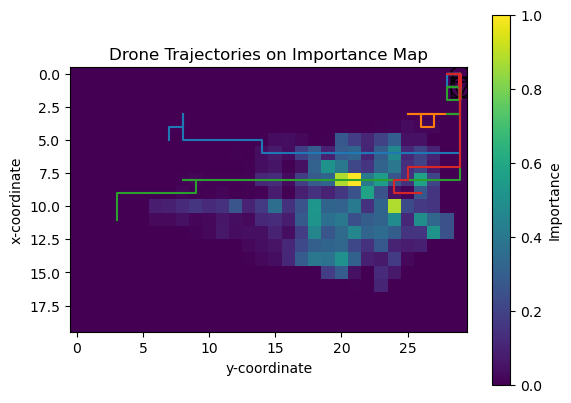

[0.39421099580070673, 0.39421099580070673, 0.39421099580070673, -0.3942102957507185]
Time | ep_step:  111 1
[-0.2692100207982143, -0.2692100207982143, -0.2692100207982143, 0.2692107707532124]
Time | ep_step:  112 2
[0.144210520773216, 0.144210520773216, 0.144210520773216, -0.1442097707782129]
Time | ep_step:  113 3
[-0.01920952077571817, -0.01920952077571817, -0.01920952077571817, 0.019210270775711778]
Time | ep_step:  114 4
[1.7202553866550896, 8.782837011777554, 6.9374432227617415, -1.7202582887458142]
-----------
Episode:  23
Time | ep_step:  115 0
[-1.5952580387458146, -8.907839663879528, -6.937445874863717, 1.5952587887458127]
Time | ep_step:  116 1
[1.470258538745814, 1.470258538745814, 1.470258538745814, -1.4702577887458157]
Time | ep_step:  117 2
[-1.3452575387458163, -1.3452575387458163, -1.3452575387458163, 1.3452582887458144]
Time | ep_step:  118 3
[1.2202580387458153, 1.2202580387458153, 1.2202580387458153, -1.220257288745817]
Time | ep_step:  119 4
[-1.0952570387458176, -1

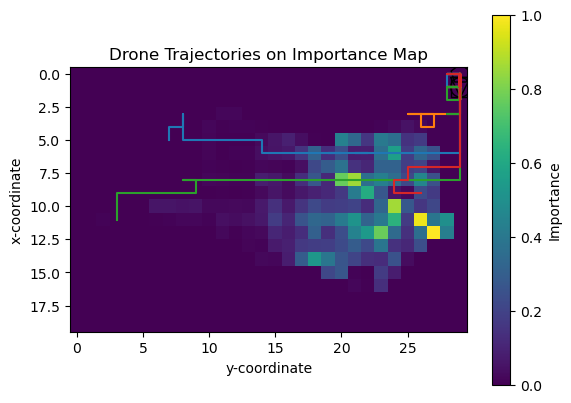

[0.9702575387458166, 0.9702575387458166, 0.9702575387458166, -0.9702567887458184]
Time | ep_step:  121 1
[-0.8452565387458191, -0.8452565387458191, -0.8452565387458191, 0.8452572887458172]
Time | ep_step:  122 2
[0.720257038745818, 0.720257038745818, 0.720257038745818, -0.7202562887458199]
Time | ep_step:  123 3
[2.1355780862541804, 2.1355780862541804, 6.187574663466732, -2.1355827979224182]
Time | ep_step:  124 4
[8.155211042512153, 8.131255397277396, -2.6587883182872035e-06, -2.7116682431536983e-07]
-----------
Episode:  25
Time | ep_step:  125 0
[-8.280214907471219, -8.131259262236462, -5.243641737263475, 0.3385585800422411]
Time | ep_step:  126 1
[-0.4635583300172416, -0.4635583300172416, 0.46355907956723974, -0.4635583300172416]
Time | ep_step:  127 2
[0.5885593297672641, 0.5885593297672641, -0.588558579817216, 0.5885593297672641]
Time | ep_step:  128 3
[-0.7135588297922626, -0.7135588297922626, 0.7135595797922157, -0.7135588297922626]
Time | ep_step:  129 4
[0.8385598297922354, 0

In [5]:
# Set mode: random, greedy, lstm, nn
mode = 'gru'

pretrained_folder = r'\GRU_13_2_10000iter REAL.pth' # r'\GRU_128_3_10000iter.pth'

run(link, df_link, ['000'], id = 'pred_vdist', mode = mode, load = True, pretrained_folder=pretrained_folder)

In [10]:
list_of_perc_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_perc_visited.npy')
list_reward_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_reward_metric.npy')
list_patrol_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_patrol_metric.npy')

In [11]:
def percentage_above(graphe1, graphe2):

    graphe1 = np.array(graphe1)
    graphe2 = np.array(graphe2)

    if len(graphe1) != len(graphe2):
        raise ValueError("Les deux graphes doivent avoir la même longueur.")

    nb_au_dessus = np.sum(graphe1 > graphe2)
    pourcentage = (nb_au_dessus / len(graphe1)) * 100

    print(f"GRU est au-dessus de LSTM dans {pourcentage:.2f}% des cas.")
    return pourcentage

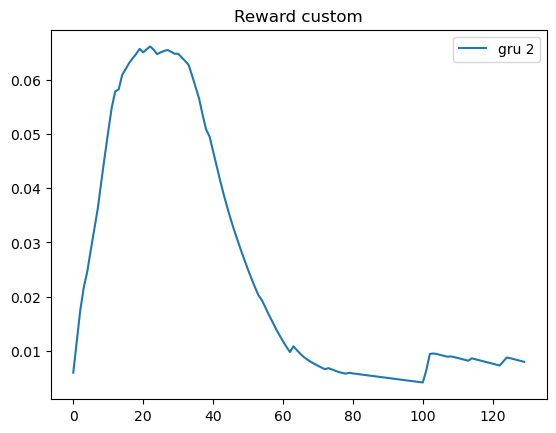

In [12]:
plt.plot(list_patrol_gru_2, label = 'gru 2')
plt.title('Reward custom')
plt.legend()

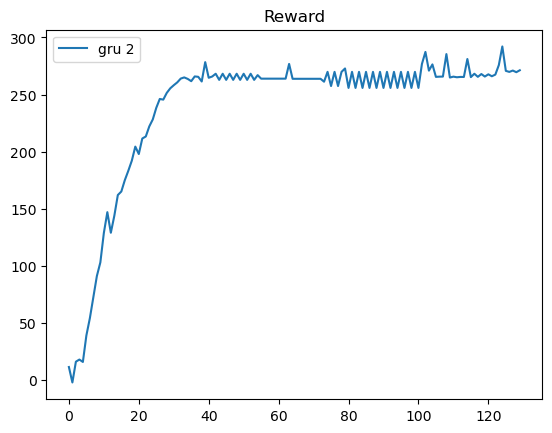

In [13]:
plt.plot(list_reward_gru_2, label = 'gru 2')
plt.title('Reward')
plt.legend()

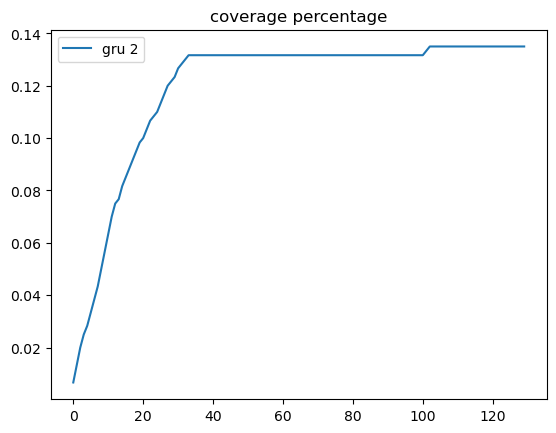

In [14]:
plt.plot(list_of_perc_gru_2, label = 'gru 2')
plt.title('coverage percentage')
plt.legend()